# Giải thích `Core/Plane.hpp` của LIMOncello

Notebook này giải thích riêng file helper dùng để:

1. **fit mặt phẳng cục bộ** từ các điểm lân cận trong map,
2. **lưu cặp (điểm nguồn, mặt phẳng tương ứng)**,
3. **tính residual point-to-plane** để đưa vào bước update của IESEKF.

Đây là đúng vai trò mà paper LIMOncello mô tả ở phần Iterated Update: với mỗi điểm LiDAR đã downsample, hệ thống tìm k-NN trong i-Octree, fit một mặt phẳng cục bộ, rồi dùng **point-to-plane constraint** để cập nhật state.

## 0. Đoạn code cần đọc

```cpp
#pragma once

#include <vector>

#include <Eigen/Dense>

#include "Utils/PCL.hpp"


inline bool estimate_plane(Eigen::Vector4d& pabcd,
                           const std::vector<pcl::PointXYZ>& pts,
                           const double& thresh) {

  int N = pts.size();
  if (N < 3)
    return false;

  Eigen::Matrix<double, Eigen::Dynamic, 3> neighbors(N, 3);
  for (size_t i = 0; i < N; i++) {
    neighbors.row(i) = pts[i].getVector3fMap().cast<double>();
  }

  Eigen::Vector3d centroid = neighbors.colwise().mean(); 
  neighbors.rowwise() -= centroid.transpose();

  Eigen::Matrix3d cov = (neighbors.transpose() * neighbors) / N;

  Eigen::SelfAdjointEigenSolver<Eigen::Matrix3d> eigensolver(cov);
  if (eigensolver.info() != Eigen::Success)
    return false;

  Eigen::Vector3d normal = eigensolver.eigenvectors().col(0);
  double d = -normal.dot(centroid);

  pabcd.head<3>() = normal;
  pabcd(3) = d;

  for (auto& p : pts) {
    double distance = normal.dot(p.getVector3fMap().cast<double>()) + d;
    if (std::abs(distance) > thresh)
      return false;
  }

  return true;
}


struct Plane {
  Eigen::Vector3d p;
  Eigen::Vector4d n; // world normal vector

  Plane() = default;
  Plane(Eigen::Vector3d& p_, Eigen::Vector4d& n_) : p(p_), n(n_) {};
};

inline double dist2plane(const Eigen::Vector4d& normal,
                         const Eigen::Vector3d& point) {
  return normal.head<3>().dot(point) + normal(3);
}


typedef std::vector<Plane> Planes;
```

## 1. Bức tranh lớn: file này đứng ở đâu trong LIMOncello?

Trong paper, bước update dùng measurement

\[
h_i(x) = u_i^\top \big(\pi(\Gamma)\,{}^I\!T_L\,p_i - q_i\big),
\]

trong đó:

- \(p_i\) là điểm LiDAR gốc,
- \(\pi(\Gamma)\,{}^I\!T_L\,p_i\) là điểm đó sau khi biến đổi lên world frame,
- \(u_i\) là pháp tuyến của mặt phẳng local fit từ các điểm lân cận trong map,
- \(q_i\) là **một điểm bất kỳ nằm trên mặt phẳng**.

Vì thế pipeline của file này là:

\[
\text{k-NN trong map}
\;\longrightarrow\;
\text{fit plane}
\;\longrightarrow\;
\text{tính } n^\top g + d
\;\longrightarrow\;
\text{đưa residual vào IESEKF}.
\]

Trong `State::update()` của LIMOncello, chuỗi gọi hàm là:

```cpp
map.knn(...);
estimate_plane(p_abcd, neighbors, plane_threshold);
planes[i] = Plane(p, p_abcd);
...
Vec<3> g = s.X.element<0>().act(s.L2I_isometry() * m.p, J_s);
z(i) = -dist2plane(m.n, g);
```

Nghĩa là:

- `estimate_plane(...)` dựng mặt phẳng từ các điểm map lân cận,
- `Plane(p, p_abcd)` ghép **điểm LiDAR nguồn** với **mặt phẳng vừa fit**,
- `dist2plane(...)` cho residual có dấu của điểm toàn cục `g` tới mặt phẳng đó.

## 2. Công thức lõi của cả file

Mặt phẳng trong không gian 3D được viết dưới dạng

\[
a x + b y + c z + d = 0
\]

hay gọn hơn:

\[
n^\top x + d = 0,
\qquad
n = \begin{bmatrix} a \\ b \\ c \end{bmatrix}.
\]

Nếu \(n\) là vector đơn vị thì:

\[
r(x) = n^\top x + d
\]

chính là **khoảng cách có dấu** từ điểm \(x\) đến mặt phẳng.

Đó cũng chính là thứ hàm `dist2plane(...)` trả ra:

```cpp
return normal.head<3>().dot(point) + normal(3);
```

Tên `dist2plane` hơi dễ gây hiểu nhầm, vì nó **không phải bình phương khoảng cách**. Nó là residual có dấu.

## 3. Vì sao `estimate_plane()` lại dùng PCA / eigen decomposition?

Hàm này đang giải bài toán **best-fit plane** theo nghĩa bình phương khoảng cách vuông góc nhỏ nhất:

\[
\min_{\|n\|=1,\, d}\; \sum_{i=1}^N (n^\top p_i + d)^2.
\]

### Bước 1: tối ưu theo \(d\)

Lấy đạo hàm theo \(d\):

\[
\frac{\partial}{\partial d}\sum_i (n^\top p_i + d)^2 = 2\sum_i (n^\top p_i + d)=0.
\]

Suy ra:

\[
d = -n^\top c,
\qquad
c = \frac1N \sum_i p_i
\]

với \(c\) là **centroid** của cụm điểm.

### Bước 2: thay ngược lại

\[
n^\top p_i + d
=
n^\top(p_i-c).
\]

Nên bài toán trở thành:

\[
\min_{\|n\|=1}\sum_{i=1}^N \big(n^\top (p_i-c)\big)^2.
\]

Đặt \(\tilde p_i = p_i-c\), rồi lập covariance

\[
C = \frac1N \sum_{i=1}^N \tilde p_i \tilde p_i^\top.
\]

Ta có:

\[
\sum_{i=1}^N \big(n^\top \tilde p_i\big)^2
= n^\top \left(\sum_i \tilde p_i \tilde p_i^\top\right)n
\propto n^\top C n.
\]

Theo Rayleigh quotient, nghiệm của

\[
\min_{\|n\|=1} n^\top C n
\]

là **eigenvector ứng với eigenvalue nhỏ nhất** của \(C\).

Đó là lý do code lấy:

```cpp
Eigen::Vector3d normal = eigensolver.eigenvectors().col(0);
```

vì `SelfAdjointEigenSolver` của Eigen trả eigenvalue theo thứ tự tăng dần.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_plane_py(points, thresh):
    # Bản Python bám sát code C++
    points = np.asarray(points, dtype=float)
    N = len(points)
    if N < 3:
        return {"ok": False, "reason": "N < 3"}

    neighbors = points.copy()
    centroid = neighbors.mean(axis=0)
    neighbors = neighbors - centroid

    cov = neighbors.T @ neighbors / N

    eigvals, eigvecs = np.linalg.eigh(cov)
    normal = eigvecs[:, 0]
    normal = normal / np.linalg.norm(normal)
    d = -normal @ centroid

    distances = points @ normal + d
    ok = np.all(np.abs(distances) <= thresh)

    return {
        "ok": bool(ok),
        "centroid": centroid,
        "cov": cov,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "normal": normal,
        "d": d,
        "plane4": np.r_[normal, d],
        "distances": distances,
    }

def dist2plane_py(plane4, point):
    plane4 = np.asarray(plane4, dtype=float)
    point = np.asarray(point, dtype=float)
    return plane4[:3] @ point + plane4[3]

def basis_from_normal(normal):
    normal = np.asarray(normal, dtype=float)
    normal = normal / np.linalg.norm(normal)
    helper = np.array([1.0, 0.0, 0.0])
    if abs(helper @ normal) > 0.9:
        helper = np.array([0.0, 1.0, 0.0])
    e1 = np.cross(normal, helper)
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(normal, e1)
    e2 = e2 / np.linalg.norm(e2)
    return e1, e2

def project_point_to_plane(plane4, point):
    n = plane4[:3]
    r = dist2plane_py(plane4, point)
    return point - r * n

## 4. Giải thích `estimate_plane()` theo từng đoạn code

### 4.1 Kiểm tra đủ số điểm

```cpp
int N = pts.size();
if (N < 3)
  return false;
```

Ít hơn 3 điểm thì chưa xác định được một mặt phẳng 3D một cách có ý nghĩa.

### 4.2 Chuyển `std::vector<pcl::PointXYZ>` sang ma trận Eigen

```cpp
Eigen::Matrix<double, Eigen::Dynamic, 3> neighbors(N, 3);
for (size_t i = 0; i < N; i++) {
  neighbors.row(i) = pts[i].getVector3fMap().cast<double>();
}
```

Sau đoạn này, `neighbors` là ma trận \(N\times 3\), mỗi hàng là một điểm 3D.

Điều hay ở đây là tác giả chuyển ngay sang ma trận để các phép:

- tính mean,
- trừ centroid,
- lập covariance

đều rất gọn.

### 4.3 Tính centroid và center dữ liệu

```cpp
Eigen::Vector3d centroid = neighbors.colwise().mean(); 
neighbors.rowwise() -= centroid.transpose();
```

Toán học tương ứng là:

\[
c = \frac1N\sum_{i=1}^N p_i,
\qquad
\tilde p_i = p_i - c.
\]

Đây là bước bắt buộc để tách riêng **vị trí trung tâm của cụm điểm** ra khỏi **hướng phẳng của cụm điểm**.

### 4.4 Lập covariance và lấy eigenvector nhỏ nhất

```cpp
Eigen::Matrix3d cov = (neighbors.transpose() * neighbors) / N;
Eigen::SelfAdjointEigenSolver<Eigen::Matrix3d> eigensolver(cov);
...
Eigen::Vector3d normal = eigensolver.eigenvectors().col(0);
```

Vì `cov` là ma trận đối xứng xác định bán dương, dùng `SelfAdjointEigenSolver` là đúng và ổn định số.

Nếu cụm điểm gần như nằm trên một mặt phẳng thì:

- sẽ có 2 hướng phương sai lớn **nằm trong mặt phẳng**,
- và 1 hướng phương sai nhỏ nhất **vuông góc với mặt phẳng**.

Hướng nhỏ nhất đó chính là **pháp tuyến**.

### 4.5 Tính hệ số \(d\)

```cpp
double d = -normal.dot(centroid);
```

Vì mặt phẳng đi qua centroid nên:

\[
n^\top c + d = 0
\quad\Longrightarrow\quad
d = -n^\top c.
\]

Sau đó code ghi mặt phẳng dưới dạng vector 4 chiều:

```cpp
pabcd.head<3>() = normal;
pabcd(3) = d;
```

nghĩa là `pabcd = [a,b,c,d]^\top`.

### 4.6 Kiểm tra ngưỡng phẳng `thresh`

```cpp
for (auto& p : pts) {
  double distance = normal.dot(p.getVector3fMap().cast<double>()) + d;
  if (std::abs(distance) > thresh)
    return false;
}
```

Bước này có nghĩa là:

> "Mặt phẳng vừa fit chỉ được chấp nhận nếu **tất cả** các điểm lân cận đều cách mặt phẳng không quá `thresh`."

Đây là một tiêu chí khá chặt. Chỉ cần một điểm lệch quá lớn là cả plane bị loại.

## 5. Ví dụ số nhỏ: fit một mặt phẳng gần-phẳng bằng PCA

In [2]:
rng = np.random.default_rng(7)

normal_true = np.array([0.35, -0.28, 0.894], dtype=float)
normal_true = normal_true / np.linalg.norm(normal_true)
centroid_true = np.array([1.0, 2.0, 0.4])

e1, e2 = basis_from_normal(normal_true)

uv = rng.uniform(-1.0, 1.0, size=(120, 2))
points = centroid_true + uv[:, [0]] * e1 + uv[:, [1]] * e2

# thêm nhiễu nhỏ theo pháp tuyến để mô phỏng mặt phẳng local ngoài đời
points = points + 0.01 * rng.normal(size=(len(points), 1)) * normal_true

result = estimate_plane_py(points, thresh=0.05)

print("Plane accepted:", result["ok"])
print("Estimated normal =", np.round(result["normal"], 4))
print("Estimated d      =", np.round(result["d"], 4))
print("Eigenvalues      =", np.round(result["eigvals"], 6))
print("Max |distance|   =", np.round(np.max(np.abs(result["distances"])), 6))

Plane accepted: True
Estimated normal = [ 0.3494 -0.283   0.8932]
Estimated d      = -0.1404
Eigenvalues      = [8.60000e-05 3.36151e-01 3.48629e-01]
Max |distance|   = 0.031505


### Cách đọc kết quả

- **Eigenvalue nhỏ nhất** rất bé: nghĩa là đám điểm rất mỏng theo hướng pháp tuyến.
- **`normal`** là pháp tuyến ước lượng.
- **`Max |distance|`** nhỏ hơn `thresh`: nên plane được chấp nhận.

## 6. Hình minh họa PCA plane fitting

Hình dưới đây minh họa đúng trực giác của `estimate_plane()`:

- các điểm là cụm điểm lân cận,
- dấu `x` là centroid,
- mũi tên là pháp tuyến ước lượng,
- tấm mặt phẳng là mặt phẳng fit tốt nhất theo PCA / total least squares.

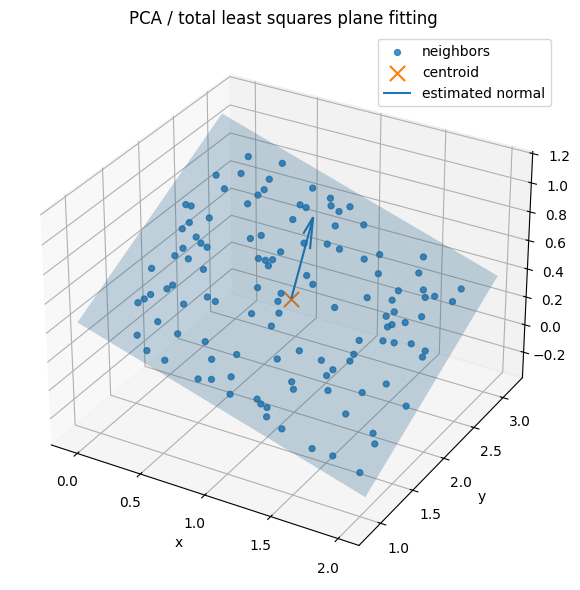

In [3]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=18, alpha=0.8, label="neighbors")

c = result["centroid"]
n = result["normal"]

ax.scatter([c[0]], [c[1]], [c[2]], marker="x", s=120, label="centroid")
ax.quiver(c[0], c[1], c[2], n[0], n[1], n[2], length=0.8, normalize=True, label="estimated normal")

b1, b2 = basis_from_normal(n)
grid = np.linspace(-1.1, 1.1, 15)
U, V = np.meshgrid(grid, grid)
plane_pts = c[None, None, :] + U[..., None] * b1 + V[..., None] * b2

ax.plot_surface(plane_pts[:, :, 0], plane_pts[:, :, 1], plane_pts[:, :, 2], alpha=0.25)

ax.set_title("PCA / total least squares plane fitting")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.tight_layout()
plt.show()

## 7. `Plane` struct thật sự lưu cái gì?

```cpp
struct Plane {
  Eigen::Vector3d p;
  Eigen::Vector4d n; // world normal vector
};
```

Tên `Plane` hơi dễ làm người mới hiểu nhầm.

### Cách hiểu đúng trong pipeline LIMOncello

- `p` **không phải** là một điểm bất kỳ nằm trên mặt phẳng.
- `p` là **điểm LiDAR nguồn** đang được gắn với mặt phẳng local này.
- `n` không chỉ là normal 3D mà là **toàn bộ hệ số mặt phẳng**
  \[
  [a,b,c,d]^\top.
  \]

Tức là mỗi phần tử `Plane` thật ra là một **cặp correspondence**:

\[
(\text{điểm LiDAR hiện tại},\ \text{mặt phẳng local trong map}).
\]

## 8. `dist2plane(...)` nối với công thức paper như thế nào?

Code:

```cpp
inline double dist2plane(const Eigen::Vector4d& normal,
                         const Eigen::Vector3d& point) {
  return normal.head<3>().dot(point) + normal(3);
}
```

Trong paper, residual được viết là

\[
h_i(x)=u_i^\top(g_i-q_i),
\]

với \(g_i\) là điểm LiDAR sau khi biến đổi lên world, \(u_i\) là pháp tuyến, và \(q_i\) là một điểm nằm trên mặt phẳng.

Nếu đặt

\[
d_i = -u_i^\top q_i,
\]

thì:

\[
h_i(x)
= u_i^\top g_i - u_i^\top q_i
= u_i^\top g_i + d_i.
\]

Đây chính là:

\[
\texttt{dist2plane}([u_i^\top, d_i]^\top, g_i).
\]

Vì vậy `dist2plane(...)` là phiên bản code rất gọn của point-to-plane residual trong paper.

In [4]:
plane4 = result["plane4"]
q_on_plane = result["centroid"]  # centroid nằm trên plane fit
g_test = q_on_plane + 0.35 * result["normal"] + 0.10 * basis_from_normal(result["normal"])[0]

residual_paper = result["normal"] @ (g_test - q_on_plane)
residual_code = dist2plane_py(plane4, g_test)

print("Residual theo paper ui^T(g - q) =", residual_paper)
print("Residual theo code dist2plane   =", residual_code)
print("Sai khác tuyệt đối              =", abs(residual_paper - residual_code))

Residual theo paper ui^T(g - q) = 0.3500000000000001
Residual theo code dist2plane   = 0.35000000000000014
Sai khác tuyệt đối              = 5.551115123125783e-17


## 9. Hình minh họa point-to-plane residual

Nếu \(g\) là một điểm ngoài mặt phẳng và \(q_\perp\) là hình chiếu vuông góc của nó lên mặt phẳng, thì:

\[
r = n^\top g + d
\]

chính là khoảng cách có dấu dọc theo pháp tuyến. Khi \(n\) là đơn vị, hình chiếu vuông góc là

\[
q_\perp = g - r\,n.
\]

Trong update của LIMOncello, filter sẽ cố kéo residual này về gần 0.

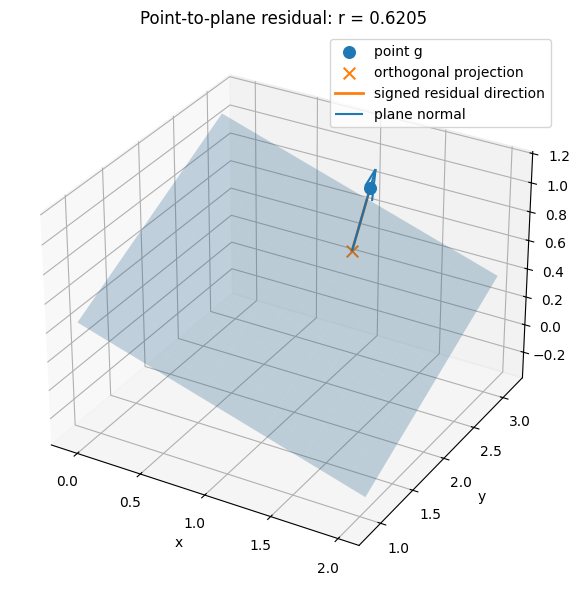

In [5]:
plane4 = result["plane4"]
n = plane4[:3]

g = np.array([1.35, 2.45, 1.10])
r = dist2plane_py(plane4, g)
q_proj = project_point_to_plane(plane4, g)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

c = result["centroid"]
b1, b2 = basis_from_normal(n)
grid = np.linspace(-1.1, 1.1, 15)
U, V = np.meshgrid(grid, grid)
plane_pts = c[None, None, :] + U[..., None] * b1 + V[..., None] * b2
ax.plot_surface(plane_pts[:, :, 0], plane_pts[:, :, 1], plane_pts[:, :, 2], alpha=0.25)

ax.scatter([g[0]], [g[1]], [g[2]], s=70, label="point g")
ax.scatter([q_proj[0]], [q_proj[1]], [q_proj[2]], s=70, marker="x", label="orthogonal projection")
ax.plot([g[0], q_proj[0]], [g[1], q_proj[1]], [g[2], q_proj[2]], linewidth=2, label="signed residual direction")

ax.quiver(q_proj[0], q_proj[1], q_proj[2], n[0], n[1], n[2], length=0.8, normalize=True, label="plane normal")

ax.set_title(f"Point-to-plane residual: r = {r:.4f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Một ví dụ nhỏ về `thresh`: thêm outlier sẽ làm plane bị loại

Đây là lý do hàm trả `bool`: không phải cụm k-NN nào cũng đáng tin để dùng làm residual.

In [6]:
# Tạo một outlier vừa phải: lệch khoảng 0.12 m theo pháp tuyến
outlier = centroid_true + 0.30 * e1 + 0.10 * e2 + 0.12 * normal_true
points_with_outlier = np.vstack([points, outlier])

ok_relaxed = estimate_plane_py(points_with_outlier, thresh=0.15)["ok"]
ok_tight = estimate_plane_py(points_with_outlier, thresh=0.05)["ok"]

print("Có outlier, thresh = 0.15 ->", ok_relaxed)
print("Có outlier, thresh = 0.05 ->", ok_tight)

Có outlier, thresh = 0.15 -> True
Có outlier, thresh = 0.05 -> False


## 11. Những chỗ dễ hiểu nhầm nhất

### `dist2plane` không phải là “distance squared”
Tên hàm hơi đánh lừa. Nó trả về:

\[
n^\top x + d,
\]

tức residual có dấu.

### `Plane.n` không chỉ là normal
`Plane.n` là cả bộ hệ số \([a,b,c,d]^\top\).

### `Plane.p` không phải điểm nằm trên plane
`Plane.p` là **điểm LiDAR nguồn** của correspondence.

### Vì sao không dùng eigenvalue ratio?
Code này chọn cách rất thực dụng:

1. fit mặt phẳng bằng PCA,
2. kiểm tra trực tiếp mọi điểm có nằm gần mặt phẳng không.

Đây là một lựa chọn triển khai gọn và dễ kiểm soát.

## 12. Tóm tắt một trang

File này có thể nhớ bằng 4 dòng:

\[
c = \frac1N\sum_i p_i
\]

\[
C = \frac1N\sum_i (p_i-c)(p_i-c)^\top
\]

\[
n = \text{eigenvector nhỏ nhất của } C,
\qquad
d = -n^\top c
\]

\[
r(g) = n^\top g + d
\]

Trong LIMOncello:

- `estimate_plane(...)` tạo ra \([n^\top,d]^\top\),
- `Plane` ghép điểm LiDAR với mặt phẳng local,
- `dist2plane(...)` tạo residual point-to-plane có dấu,
- residual đó đi vào IESEKF để sửa state.

Nếu bạn đọc lại `State::update()` sau notebook này, bạn sẽ thấy phần plane fitting và phần residual point-to-plane dễ hiểu hơn rất nhiều.